# Fire2Air Darwin — Assessment 3
## 05 Visualisation, Integration, Tomorrow Smoke Outlook and Documentation
**Member:** Dieu Yen Diep

Assessment 3 upgrades:
- visualises FSI, aligned/upwind FRP and next-day PM2.5 relationships;
- consolidates model, station, cross-station and ablation results;
- integrates the three predictions into a station-specific Tomorrow Smoke Outlook;
- creates dashboard-ready decision-support output with explicit reliability rules;
- updates the evidence manifest and README for the Assessment 3 run order;
- keeps API/dashboard deployment as optional future layers unless actually implemented.

In [7]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
%pip install boto3
%pip install "botocore[crt]"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [9]:
# ============================================================
# AWS S3 CONFIGURATION
# ============================================================
import boto3
import shutil

BUCKET = "fire2air-darwin-dan5-646468992009-ap-southeast-2-an"

NTEPA_RAW = f"s3://{BUCKET}/raw/ntepa/"
FIRMS_RAW = f"s3://{BUCKET}/raw/firms/"
NTEPA_DAILY = f"s3://{BUCKET}/processed/ntepa_daily/"
FIRMS_DAILY = f"s3://{BUCKET}/processed/firms_daily/"
MODEL_READY = f"s3://{BUCKET}/processed/model_ready/"
MODEL1_DIR = f"s3://{BUCKET}/models/model1/"
MODEL2_DIR = f"s3://{BUCKET}/models/model2/"
MODEL3_DIR = f"s3://{BUCKET}/models/model3/"
MODEL1_OUTPUT = f"s3://{BUCKET}/outputs/model1/"
MODEL2_OUTPUT = f"s3://{BUCKET}/outputs/model2/"
MODEL3_OUTPUT = f"s3://{BUCKET}/outputs/model3/"
VIS_OUTPUT = f"s3://{BUCKET}/outputs/visualisation/"
DASHBOARD_DIR = f"s3://{BUCKET}/dashboard/"
DOCUMENTATION_DIR = f"s3://{BUCKET}/documentation/"
ATHENA_RESULTS = f"s3://{BUCKET}/athena-results/"

s3 = boto3.client("s3")
LOCAL_ROOT = Path("/tmp/fire2air_a3")
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

def _prefix(uri):
    return uri.replace(f"s3://{BUCKET}/", "", 1)

def download_prefix(uri, local_dir, flatten=False):
    local_dir = Path(local_dir)
    local_dir.mkdir(parents=True, exist_ok=True)
    prefix = _prefix(uri)
    paginator = s3.get_paginator("list_objects_v2")
    downloaded = []
    for page in paginator.paginate(Bucket=BUCKET, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if key.endswith("/"):
                continue
            rel = Path(key[len(prefix):].lstrip("/"))
            dest = local_dir / (rel.name if flatten else rel)
            dest.parent.mkdir(parents=True, exist_ok=True)
            s3.download_file(BUCKET, key, str(dest))
            downloaded.append(dest)
    return downloaded

def upload_file(local_path, uri, object_name=None):
    local_path = Path(local_path)
    prefix = _prefix(uri).rstrip("/")
    key = f"{prefix}/{object_name or local_path.name}"
    s3.upload_file(str(local_path), BUCKET, key)
    print(f"Uploaded: s3://{BUCKET}/{key}")

def upload_tree(local_dir, uri):
    local_dir = Path(local_dir)
    if not local_dir.exists():
        return
    prefix = _prefix(uri).rstrip("/")
    for p in local_dir.rglob("*"):
        if p.is_file():
            rel = p.relative_to(local_dir).as_posix()
            key = f"{prefix}/{rel}"
            s3.upload_file(str(p), BUCKET, key)
    print(f"Uploaded folder: {local_dir} -> {uri}")

In [10]:
project_folder = LOCAL_ROOT / "visualisation_workspace"
if project_folder.exists():
    shutil.rmtree(project_folder)
project_folder.mkdir(parents=True, exist_ok=True)

# Shared datasets from Script 01.
download_prefix(MODEL_READY, project_folder, flatten=True)
download_prefix(NTEPA_DAILY, project_folder, flatten=True)
download_prefix(FIRMS_DAILY, project_folder, flatten=True)

output_root = project_folder / "outputs_prt661_a3"
table_dir = output_root / "tables"
figure_dir = output_root / "figures"
for folder in [table_dir, figure_dir]:
    folder.mkdir(parents=True, exist_ok=True)

# Bring model tables produced by Scripts 02-04 into the consolidation workspace.
download_prefix(MODEL1_OUTPUT + "tables/", table_dir, flatten=True)
download_prefix(MODEL2_OUTPUT + "tables/", table_dir, flatten=True)
download_prefix(MODEL3_OUTPUT + "tables/", table_dir, flatten=True)

model_table = pd.read_csv(
    project_folder / "Fire2Air_model_ready_checkpoint_A3.csv",
    parse_dates=["date", "target_date"],
)
daily_air = pd.read_csv(
    project_folder / "Fire2Air_ntepa_daily_checkpoint_A3.csv",
    parse_dates=["date"],
)
fire_daily = pd.read_csv(
    project_folder / "Fire2Air_firms_daily_checkpoint_A3.csv",
    parse_dates=["date_darwin"],
)
with open(project_folder / "Fire2Air_feature_manifest_A3.json", "r", encoding="utf-8") as f:
    manifest = json.load(f)
model_features = manifest["features"]
PM25_THRESHOLD = float(manifest["threshold_pm25_ug_m3"])
MAX_FIRE_DISTANCE_KM = float(manifest["max_fire_distance_km"])

print("Project folder:", project_folder)
print("Model-ready rows:", len(model_table))
print("Predictors:", len(model_features))

Project folder: \tmp\fire2air_a3\visualisation_workspace
Model-ready rows: 7530
Predictors: 93


## A. Updated Assessment 3 architecture

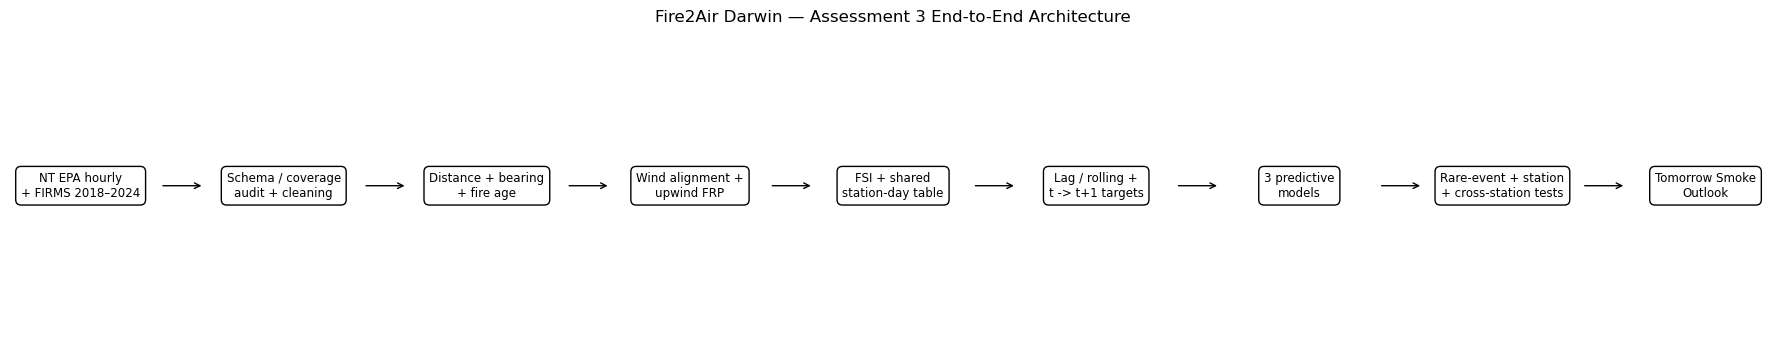

In [11]:
stages = [
    "NT EPA hourly\n+ FIRMS 2018–2024",
    "Schema / coverage\naudit + cleaning",
    "Distance + bearing\n+ fire age",
    "Wind alignment +\nupwind FRP",
    "FSI + shared\nstation-day table",
    "Lag / rolling +\nt -> t+1 targets",
    "3 predictive\nmodels",
    "Rare-event + station\n+ cross-station tests",
    "Tomorrow Smoke\nOutlook",
]
fig, ax = plt.subplots(figsize=(18, 3.5))
ax.axis("off")
xs = np.linspace(0.04, 0.96, len(stages))
for i, (x, label) in enumerate(zip(xs, stages)):
    ax.text(
        x, 0.5, label, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="black"),
        transform=ax.transAxes, fontsize=8.5,
    )
    if i < len(stages) - 1:
        ax.annotate(
            "", xy=(xs[i + 1] - 0.045, 0.5), xytext=(x + 0.045, 0.5),
            xycoords=ax.transAxes, textcoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->"),
        )
ax.set_title("Fire2Air Darwin — Assessment 3 End-to-End Architecture", pad=14)
fig.tight_layout()
fig.savefig(figure_dir / "a3_01_updated_architecture.png", dpi=180, bbox_inches="tight")
plt.show()

## B. Core EDA: PM2.5 trend, station distribution and exceedance frequency

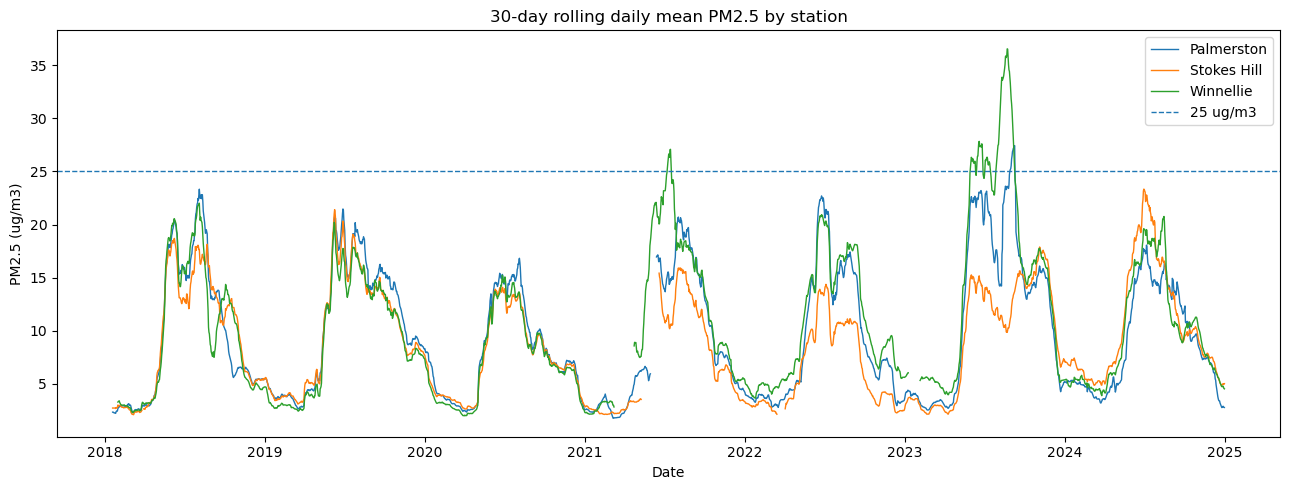

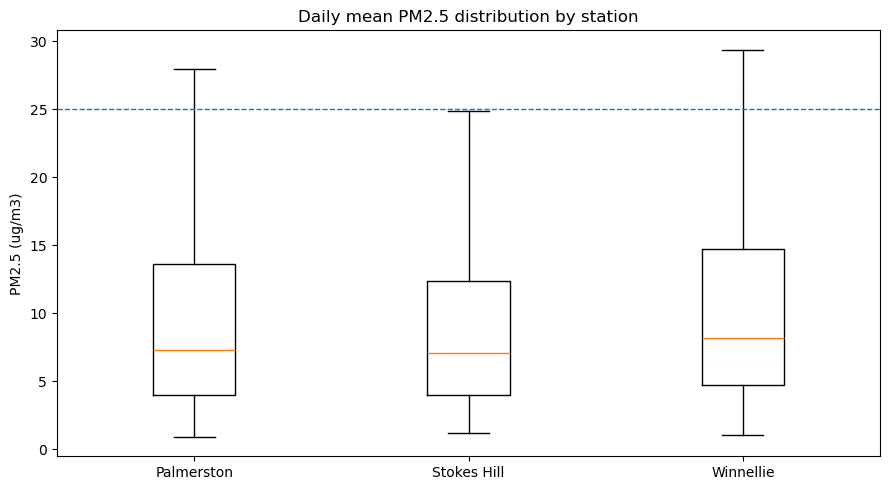

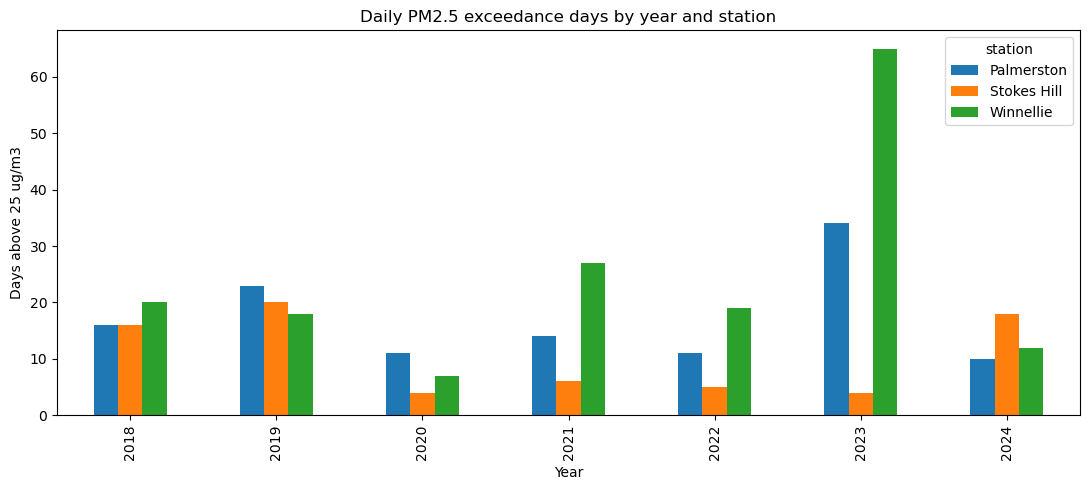

In [23]:
fig, ax = plt.subplots(figsize=(13, 5))
for station, g in daily_air.sort_values("date").groupby("station"):
    smoothed = g.set_index("date")["pm25_mean"].rolling(30, min_periods=10).mean()
    ax.plot(smoothed.index, smoothed.values, label=station, linewidth=1)
ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1, label="25 ug/m3")
ax.set_title("30-day rolling daily mean PM2.5 by station")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (ug/m3)")
ax.legend()
fig.tight_layout()
fig.savefig(figure_dir / "a3_02_pm25_trend_by_station.png", dpi=180, bbox_inches="tight")
plt.show()

stations = sorted(daily_air["station"].dropna().unique())
data = [daily_air.loc[daily_air["station"].eq(s), "pm25_mean"].dropna() for s in stations]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data, tick_labels=stations, showfliers=False)
ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1)
ax.set_title("Daily mean PM2.5 distribution by station")
ax.set_ylabel("PM2.5 (ug/m3)")
fig.tight_layout()
fig.savefig(figure_dir / "a3_03_pm25_distribution_by_station.png", dpi=180, bbox_inches="tight")
plt.show()

exceedance_counts = (
    daily_air.dropna(subset=["pm25_mean"])
    .assign(year=lambda d: d["date"].dt.year, exceedance=lambda d: (d["pm25_mean"] > PM25_THRESHOLD).astype(int))
    .groupby(["year", "station"])["exceedance"].sum()
    .unstack("station").fillna(0)
)
ax = exceedance_counts.plot(kind="bar", figsize=(11, 5))
ax.set_title("Daily PM2.5 exceedance days by year and station")
ax.set_xlabel("Year")
ax.set_ylabel("Days above 25 ug/m3")
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(figure_dir / "a3_04_exceedance_days_by_year_station.png", dpi=180, bbox_inches="tight")
plt.show()

## C. Assessment 3 novelty visualisations: FSI, aligned FRP and upwind FRP

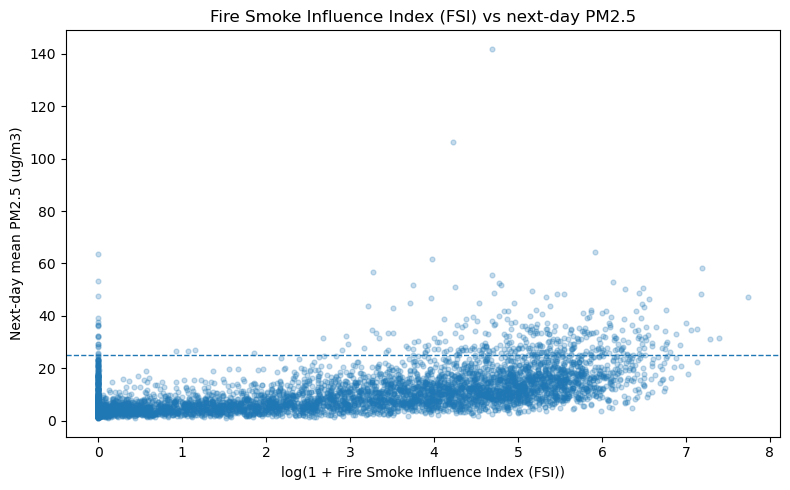

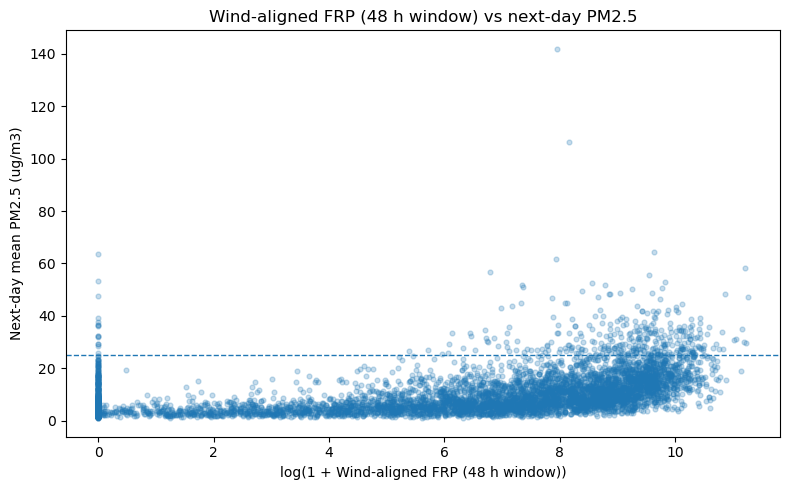

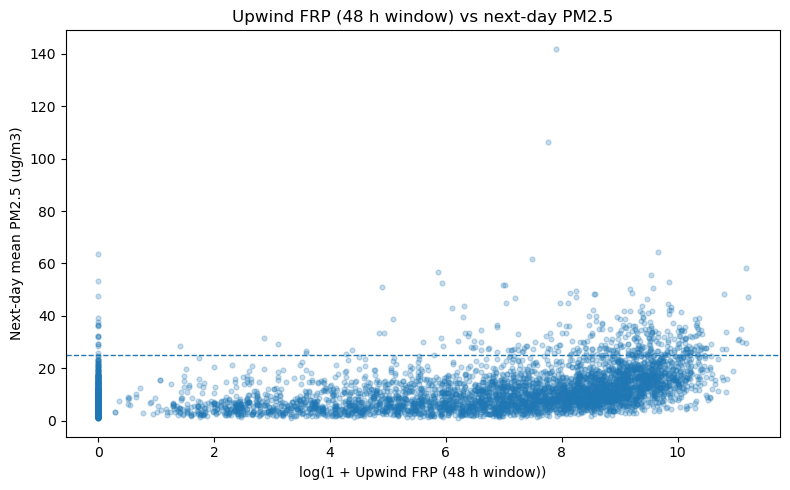

In [16]:
novelty_specs = [
    ("fsi_total", "Fire Smoke Influence Index (FSI)", "a3_05_fsi_vs_next_day_pm25.png"),
    ("aligned_frp_sum", "Wind-aligned FRP (48 h window)", "a3_06_aligned_frp_vs_next_day_pm25.png"),
    ("upwind_frp_sum", "Upwind FRP (48 h window)", "a3_07_upwind_frp_vs_next_day_pm25.png"),
]
for feature, label, filename in novelty_specs:
    if feature not in model_table.columns:
        continue
    plot_data = model_table.dropna(subset=[feature, "target_pm25_next_day"]).copy()
    if plot_data.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(np.log1p(plot_data[feature].clip(lower=0)), plot_data["target_pm25_next_day"], alpha=0.25, s=12)
    ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1)
    ax.set_xlabel(f"log(1 + {label})")
    ax.set_ylabel("Next-day mean PM2.5 (ug/m3)")
    ax.set_title(f"{label} vs next-day PM2.5")
    fig.tight_layout()
    fig.savefig(figure_dir / filename, dpi=180, bbox_inches="tight")
    plt.show()

# FSI summaries by year and station.
if "fsi_total" in model_table.columns:
    fsi_station_year = (
        model_table.assign(year=model_table["date"].dt.year)
        .groupby(["year", "station"])["fsi_total"]
        .agg(["count", "mean", "median", "max"])
        .reset_index()
    )
    fsi_station_year.to_csv(table_dir / "a3_eda_fsi_by_station_year.csv", index=False)

## D. Wind-alignment evidence and data coverage

In [17]:
if "alignment_mean" in model_table.columns:
    alignment_summary = (
        model_table.groupby("station")["alignment_mean"]
        .agg(["count", "mean", "median", "max"])
        .reset_index()
    )
    alignment_summary.to_csv(table_dir / "a3_eda_alignment_summary_by_station.csv", index=False)

coverage_cols = [
    "pm25_coverage_ratio", "pm10_coverage_ratio", "humidity_coverage_ratio",
    "temperature_coverage_ratio", "wind_speed_coverage_ratio", "pressure_coverage_ratio",
    "wind_direction_coverage_ratio", "firms_local_day_complete", "firms_48h_complete",
]
coverage_cols = [c for c in coverage_cols if c in model_table.columns]
coverage_summary = (
    model_table.assign(year=model_table["date"].dt.year)
    .groupby(["year", "station"])[coverage_cols]
    .mean()
    .reset_index()
)
coverage_summary.to_csv(table_dir / "a3_data_reliability_summary.csv", index=False)

## E. Consolidate final model metrics and Assessment 3 diagnostics

In [18]:
metric_files = {
    "Model 1 - Classification": table_dir / "a3_model1_final_2024_metrics.csv",
    "Model 2 - Regression": table_dir / "a3_model2_final_2024_metrics.csv",
    "Model 3 - Count": table_dir / "a3_model3_final_2024_metrics.csv",
}
summary_parts = []
for task, path in metric_files.items():
    if path.exists():
        x = pd.read_csv(path)
        x.insert(0, "Task", task)
        summary_parts.append(x)
    else:
        print("Missing final model result — run corresponding script:", path.name)
if summary_parts:
    final_model_summary = pd.concat(summary_parts, ignore_index=True, sort=False)
    final_model_summary.to_csv(table_dir / "a3_final_2024_model_summary.csv", index=False)
else:
    final_model_summary = pd.DataFrame()

# Consolidate station-level results.
station_metric_files = {
    "Classification": table_dir / "a3_model1_2024_metrics_by_station.csv",
    "Regression": table_dir / "a3_model2_2024_metrics_by_station.csv",
    "Count": table_dir / "a3_model3_2024_metrics_by_station.csv",
}
station_parts = []
for task, path in station_metric_files.items():
    if path.exists():
        x = pd.read_csv(path)
        x.insert(0, "Task", task)
        station_parts.append(x)
if station_parts:
    pd.concat(station_parts, ignore_index=True, sort=False).to_csv(
        table_dir / "a3_all_models_station_level_metrics.csv", index=False
    )

# Consolidate leave-one-station-out results.
loso_metric_files = {
    "Classification": table_dir / "a3_model1_leave_one_station_out.csv",
    "Regression": table_dir / "a3_model2_leave_one_station_out.csv",
    "Count": table_dir / "a3_model3_leave_one_station_out.csv",
}
loso_parts = []
for task, path in loso_metric_files.items():
    if path.exists():
        x = pd.read_csv(path)
        x.insert(0, "Task", task)
        loso_parts.append(x)
if loso_parts:
    pd.concat(loso_parts, ignore_index=True, sort=False).to_csv(
        table_dir / "a3_all_models_leave_one_station_out.csv", index=False
    )

# Consolidate ablation results.
ablation_metric_files = {
    "Classification": table_dir / "a3_model1_ablation_results.csv",
    "Regression": table_dir / "a3_model2_ablation_results.csv",
    "Count": table_dir / "a3_model3_ablation_results.csv",
}
ablation_parts = []
for task, path in ablation_metric_files.items():
    if path.exists():
        x = pd.read_csv(path)
        x.insert(0, "Task", task)
        ablation_parts.append(x)
if ablation_parts:
    ablation_all = pd.concat(ablation_parts, ignore_index=True, sort=False)
    ablation_all.to_csv(table_dir / "a3_all_models_ablation_results.csv", index=False)
else:
    ablation_all = pd.DataFrame()

## F. Integrated Tomorrow Smoke Outlook
This combines the three complementary predictions:
1) whether elevated PM2.5 is expected,
2) how severe the daily mean may be,
3) how long elevated exposure may last.

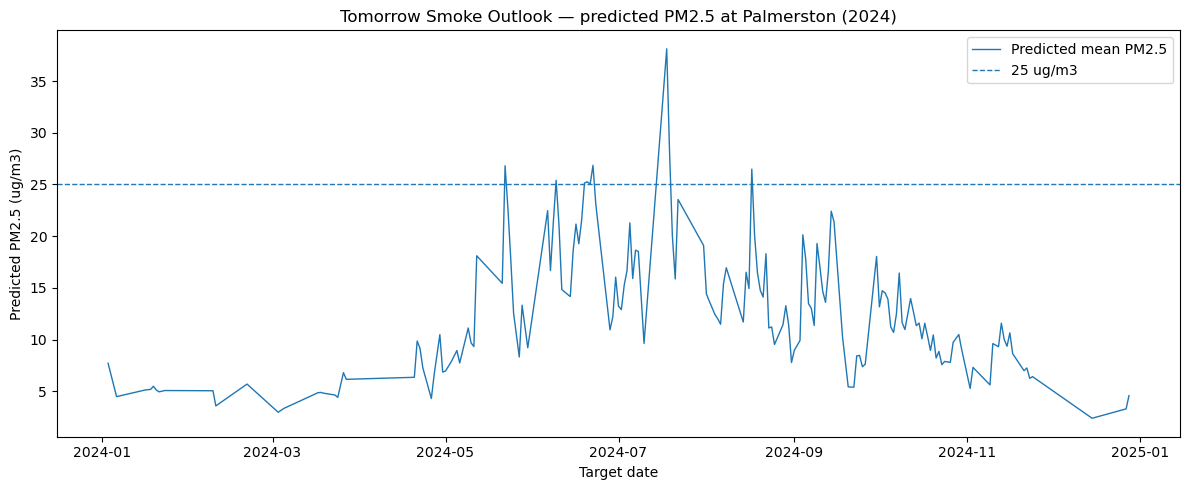

In [20]:
cls_path = table_dir / "a3_model1_2024_predictions.csv"
reg_path = table_dir / "a3_model2_2024_predictions.csv"
cnt_path = table_dir / "a3_model3_2024_predictions.csv"

if cls_path.exists() and reg_path.exists() and cnt_path.exists():
    cls = pd.read_csv(cls_path, parse_dates=["date", "target_date"])
    reg = pd.read_csv(reg_path, parse_dates=["date", "target_date"])
    cnt = pd.read_csv(cnt_path, parse_dates=["date", "target_date"])

    cls_keep = ["date", "target_date", "station", "predicted_probability", "predicted_class"]
    reg_keep = ["date", "target_date", "station", "prediction"]
    cnt_keep = ["date", "target_date", "station", "bounded_prediction_0_24"]

    outlook = (
        cls[cls_keep]
        .merge(reg[reg_keep], on=["date", "target_date", "station"], how="inner", validate="one_to_one")
        .merge(cnt[cnt_keep], on=["date", "target_date", "station"], how="inner", validate="one_to_one")
    )

    context_cols = [
        "date", "target_date", "station", "fsi_total", "aligned_frp_sum", "upwind_frp_sum",
        "nearest_upwind_fire_km", "pm25_mean", "wind_speed_mean",
        "pm25_coverage_ratio", "humidity_coverage_ratio", "wind_speed_coverage_ratio",
        "wind_direction_coverage_ratio", "firms_local_day_complete", "firms_48h_complete",
    ]
    context_cols = [c for c in context_cols if c in model_table.columns]
    outlook = outlook.merge(
        model_table[context_cols],
        on=["date", "target_date", "station"],
        how="left",
        validate="one_to_one",
    )

    outlook = outlook.rename(columns={
        "predicted_probability": "elevated_pm25_probability",
        "predicted_class": "elevated_pm25_prediction",
        "prediction": "expected_daily_mean_pm25",
        "bounded_prediction_0_24": "expected_elevated_hours",
    })

    # Define smoke-influence labels using pre-2024 non-zero FSI values so the 2024 test
    # remains untouched when thresholds are created.
    dev_fsi = model_table.loc[
        model_table["target_date"].dt.year <= 2023, "fsi_total"
    ].dropna()
    dev_fsi_nonzero = dev_fsi[dev_fsi > 0]
    if len(dev_fsi_nonzero):
        fsi_q50 = float(dev_fsi_nonzero.quantile(0.50))
        fsi_q80 = float(dev_fsi_nonzero.quantile(0.80))
    else:
        fsi_q50, fsi_q80 = 0.0, 0.0

    def smoke_influence_label(value):
        if pd.isna(value):
            return "Unknown"
        if value <= 0:
            return "Minimal"
        if value <= fsi_q50:
            return "Low"
        if value <= fsi_q80:
            return "Moderate"
        return "High"

    outlook["fire_smoke_influence"] = outlook.get("fsi_total", pd.Series(np.nan, index=outlook.index)).apply(smoke_influence_label)

    # Defined reliability rule based on current predictor-day data coverage.
    reliability_inputs = [
        c for c in [
            "pm25_coverage_ratio", "humidity_coverage_ratio", "wind_speed_coverage_ratio",
            "wind_direction_coverage_ratio", "firms_local_day_complete", "firms_48h_complete",
        ] if c in outlook.columns
    ]
    outlook["input_reliability_score"] = outlook[reliability_inputs].mean(axis=1)
    outlook["input_reliability"] = pd.cut(
        outlook["input_reliability_score"],
        bins=[-np.inf, 0.75, 0.90, np.inf],
        labels=["Limited", "Moderate", "High"],
        right=False,
    ).astype(str)

    def decision_support(row):
        risk = row["elevated_pm25_probability"]
        mean_pm = row["expected_daily_mean_pm25"]
        hours = row["expected_elevated_hours"]
        if (risk < 0.30) and (mean_pm < PM25_THRESHOLD) and (hours < 1):
            return "Lower predicted next-day smoke concern; continue checking official air-quality information."
        if (risk >= 0.50) or (mean_pm >= PM25_THRESHOLD) or (hours >= 6):
            return "Elevated smoke conditions are possible; review outdoor plans and official NT EPA information."
        return "Some smoke impact is possible; monitor updated conditions and official information."

    outlook["decision_support_summary"] = outlook.apply(decision_support, axis=1)
    outlook["disclaimer"] = (
        "Research decision-support prototype only; not an official NT EPA warning or medical advice."
    )
    outlook.to_csv(table_dir / "Fire2Air_Tomorrow_Smoke_Outlook_2024_A3.csv", index=False)
    outlook.to_csv(project_folder / "Fire2Air_dashboard_ready_outlook_A3.csv", index=False)

    with open(table_dir / "a3_smoke_outlook_thresholds.json", "w", encoding="utf-8") as f:
        json.dump({
            "fsi_low_median_nonzero": fsi_q50,
            "fsi_high_80th_nonzero": fsi_q80,
            "reliability_rule": "Limited <0.75; Moderate 0.75-<0.90; High >=0.90",
            "decision_support_note": "Research support only, not official warning/medical advice",
        }, f, indent=2)

    # Example time-series of the integrated outputs for one station.
    example_station = sorted(outlook["station"].dropna().unique())[0]
    ex = outlook[outlook["station"].eq(example_station)].sort_values("target_date")
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(ex["target_date"], ex["expected_daily_mean_pm25"], label="Predicted mean PM2.5", linewidth=1)
    ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1, label="25 ug/m3")
    ax.set_title(f"Tomorrow Smoke Outlook — predicted PM2.5 at {example_station} (2024)")
    ax.set_xlabel("Target date")
    ax.set_ylabel("Predicted PM2.5 (ug/m3)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(figure_dir / "a3_08_tomorrow_smoke_outlook_example.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Tomorrow Smoke Outlook not generated: run all three Assessment 3 model scripts first.")

## G. Evidence manifest and README
No GitHub/Jira evidence is fabricated; add only genuine team evidence separately.

In [21]:
evidence_manifest = pd.DataFrame([
    ["Raw data coverage", "tables/a3_firms_year_coverage_2018_2024.csv", "Verifies FIRMS years 2018–2024"],
    ["NT EPA quality", "tables/a3_epa_missing_pct_year_station_variable.csv", "Year x station x variable missingness"],
    ["Cleaning log", "tables/a3_epa_cleaning_log.csv", "Auditable cleaning rules"],
    ["Pressure/rainfall", "tables/a3_epa_pressure_unit_audit.csv; tables/a3_epa_rainfall_station_behaviour_audit.csv", "Station-specific harmonisation"],
    ["Advanced fire engineering", "Fire2Air_firms_daily_checkpoint_A3.csv", "Distance, age, alignment, upwind and FSI features"],
    ["Shared model dataset", "Fire2Air_model_ready_checkpoint_A3.csv; Fire2Air_feature_manifest_A3.json", "Single trusted feature table"],
    ["Ablation", "tables/a3_model1/model2/model3_ablation_results.csv", "Incremental value of A–F feature groups"],
    ["Rare-event evaluation", "tables/a3_model1_false_negative_analysis_by_station.csv; a3_model2_2024_stratified_metrics.csv; a3_model3_2024_duration_strata.csv", "Performance on important uncommon outcomes"],
    ["Station diagnostics", "tables/a3_all_models_station_level_metrics.csv", "Palmerston/Winnellie/Stokes Hill separately"],
    ["Cross-station transfer", "tables/a3_all_models_leave_one_station_out.csv", "Leave-one-station-out results"],
    ["Explainability", "figures/a3_model3_shap_*; figures/a3_model3_count_permutation_importance.png", "SHAP/permutation evidence"],
    ["Novelty plots", "figures/a3_05...a3_07", "FSI/aligned/upwind fire relationships"],
    ["Integrated decision support", "Fire2Air_dashboard_ready_outlook_A3.csv", "Three-model Tomorrow Smoke Outlook"],
    ["Governance", "ADD REAL GitHub/Jira/team evidence", "Must come from genuine project activity"],
], columns=["Assessment3_Area", "Evidence", "Purpose"])
evidence_manifest.to_csv(table_dir / "a3_evidence_manifest.csv", index=False)

readme_text = f"""# Fire2Air Darwin — Assessment 3 Technical Workflow

## Assessment 3 question
Can Fire2Air become more physically meaningful, robust, transferable and actionable?

## Run order
1. `01_Thi_Pham_Assessment3_Data_Processing_Feature_Engineering.py`
2. `02_Lihini_Jinanjalie_Assessment3_Model1_Classification.py`
3. `03_Esangbedo_Favour_Assessment3_Model2_Regression.py`
4. `04_Navodya_Piumanthi_Assessment3_Model3_Count_Explainability.py`
5. `05_Dieu_Yen_Diep_Assessment3_Visualisation_Documentation.py`

## Core novelty
Fire Smoke Influence Index (FSI): a transparent research feature combining fire intensity,
distance decay, wind alignment, wind speed, fire age and confidence weighting.
FSI is not a validated atmospheric dispersion model.

## Shared modelling design
- Predictor day: t
- Target day: exactly t+1
- Classification: next-day 24-hour mean PM2.5 > {PM25_THRESHOLD:g} ug/m3
- Regression: next-day 24-hour mean PM2.5
- Count: next-day number of hours >= {PM25_THRESHOLD:g} ug/m3
- Training target dates: 2018–2022
- Validation target dates: 2023
- Untouched final test target dates: 2024
- FIRMS range: station-specific features to {MAX_FIRE_DISTANCE_KM:g} km

## Assessment 3 evidence
- A–F ablation: air/weather -> basic fire -> FRP -> age -> wind alignment -> full FSI
- High-PM2.5/rare-event evaluation
- Station-level evaluation
- Leave-one-station-out validation
- Classifier calibration
- SHAP/permutation importance
- Tomorrow Smoke Outlook

## Future automation
The preprocessing script contains an optional NASA FIRMS Area API helper. Historical
2018–2024 evaluation remains based on the supplied archive files for reproducibility.
Cloud storage/dashboard automation should be described as future work unless actually implemented.

## Decision-support statement
Fire2Air Darwin is a research/decision-support prototype. It is not an official NT EPA
warning and is not medical advice. Feature importance and FSI show predictive relationships,
not proof of causation.
"""
readme_path = project_folder / "README_Fire2Air_Assessment3.md"
readme_path.write_text(readme_text, encoding="utf-8")
print("README saved:", readme_path.name)

README saved: README_Fire2Air_Assessment3.md


## H. Publish dashboard, visualisation and documentation artefacts to AWS S3

In [22]:
upload_tree(table_dir, VIS_OUTPUT + "tables/")
upload_tree(figure_dir, VIS_OUTPUT + "figures/")

dashboard_file = project_folder / "Fire2Air_dashboard_ready_outlook_A3.csv"
if dashboard_file.exists():
    upload_file(dashboard_file, DASHBOARD_DIR)

readme_file = project_folder / "README_Fire2Air_Assessment3.md"
if readme_file.exists():
    upload_file(readme_file, DOCUMENTATION_DIR)

manifest_file = table_dir / "a3_evidence_manifest.csv"
if manifest_file.exists():
    upload_file(manifest_file, DOCUMENTATION_DIR)

print("AWS publishing complete for Script 05.")

Uploaded folder: \tmp\fire2air_a3\visualisation_workspace\outputs_prt661_a3\tables -> s3://fire2air-darwin-dan5-646468992009-ap-southeast-2-an/outputs/visualisation/tables/
Uploaded folder: \tmp\fire2air_a3\visualisation_workspace\outputs_prt661_a3\figures -> s3://fire2air-darwin-dan5-646468992009-ap-southeast-2-an/outputs/visualisation/figures/
Uploaded: s3://fire2air-darwin-dan5-646468992009-ap-southeast-2-an/dashboard/Fire2Air_dashboard_ready_outlook_A3.csv
Uploaded: s3://fire2air-darwin-dan5-646468992009-ap-southeast-2-an/documentation/README_Fire2Air_Assessment3.md
Uploaded: s3://fire2air-darwin-dan5-646468992009-ap-southeast-2-an/documentation/a3_evidence_manifest.csv
AWS publishing complete for Script 05.
